# 02 — Preprocesado y construcción del dataset modelable

**Caso de uso:** Predicción de Diagnóstico de Cáncer  
**Asignatura:** Inteligencia Artificial — UAX 2025/2026  
**Autor:** Álvaro Santamaría Antón

## Propósito

Este notebook **no contiene lógica de preprocesado**: simplemente ejecuta el pipeline definido en `src/preprocessing.py` y valida visualmente que los datos quedan bien preparados para entrenar los modelos.

## Pipeline aplicado

1. Carga del `df_master` (50.001 × 38) desde `src/data_loader.py`
2. Selección de las **21 features** acordadas en el EDA
3. Codificación ordinal de `actividad_fisica` (Baja=0, Moderada=1, Alta=2)
4. Split estratificado **60% train / 20% val / 20% test** (random_state=42)
5. Escalado con `StandardScaler` (ajustado solo con train)
6. Cálculo de `class_weights` balanceados

## Salida persistida

- `data/processed/X_*.parquet`, `y_*.parquet` (3 splits × 2 = 6 ficheros)
- `models/scaler.joblib` (StandardScaler entrenado)
- `data/processed/preprocessing_meta.json` (metadatos)

## Imports y ejecución del pipeline

In [1]:
# === Imports ===
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Hacemos que Python pueda importar desde /src/
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_master_dataset
from src.preprocessing import prepare_data, save_splits, FEATURES_FINALES, TARGET

# Configuración visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

# === Ejecución del pipeline ===
print("Cargando df_master...")
df_master = load_master_dataset(verbose=False)
print(f"  shape: {df_master.shape}\n")

print("Ejecutando pipeline de preprocesado...\n")
data = prepare_data(df_master, verbose=True)

Cargando df_master...
  shape: (50001, 38)

Ejecutando pipeline de preprocesado...

  PIPELINE DE PREPROCESADO COMPLETADO
  Features seleccionadas: 21
  Splits (train/val/test):
    train → 30,000 muestras  |  positivos: 5,786 (19.29%)
    val   → 10,000 muestras  |  positivos: 1,929 (19.29%)
    test  → 10,001 muestras  |  positivos: 1,929 (19.29%)
  Class weights: {0: 0.6194763360039647, 1: 2.5924645696508812}
  Escalado: media de X_train ≈ 0, std ≈ 1
    media columna 0: -0.000000
    std columna 0:   +1.000000


## Validación 1: Estratificación perfecta entre splits

  VALIDACIÓN: ESTRATIFICACIÓN


,split,n_total,n_negativos,n_positivos,prevalencia_%
0,train,30000,24214,5786,19.2867
1,val,10000,8071,1929,19.2900
2,test,10001,8072,1929,19.2881


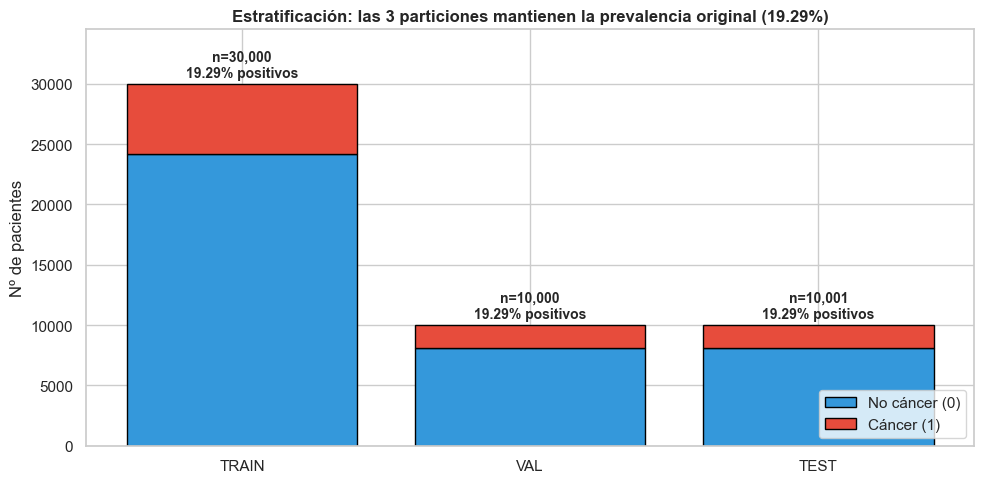


Las 3 prevalencias son idénticas → la estratificación funciona correctamente.


In [2]:
# === VALIDACIÓN 1: Distribución de la clase positiva en cada split ===
print("=" * 60)
print("  VALIDACIÓN: ESTRATIFICACIÓN")
print("=" * 60)

splits_info = []
for split in ["train", "val", "test"]:
    y = data[f"y_{split}"]
    n = len(y)
    n_pos = int(y.sum())
    n_neg = n - n_pos
    prev = n_pos / n * 100
    splits_info.append({
        "split": split,
        "n_total": n,
        "n_negativos": n_neg,
        "n_positivos": n_pos,
        "prevalencia_%": round(prev, 4),
    })

df_splits = pd.DataFrame(splits_info)
display(df_splits)

# Visualización: barras apiladas comparando los 3 splits
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_splits))
ax.bar(x, df_splits["n_negativos"], label="No cáncer (0)",
       color="#3498db", edgecolor="black")
ax.bar(x, df_splits["n_positivos"], bottom=df_splits["n_negativos"],
       label="Cáncer (1)", color="#e74c3c", edgecolor="black")

# Etiquetas con la prevalencia
for i, row in df_splits.iterrows():
    total = row["n_total"]
    ax.text(i, total + 600, f"n={total:,}\n{row['prevalencia_%']:.2f}% positivos",
            ha="center", fontweight="bold", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels([s.upper() for s in df_splits["split"]])
ax.set_ylabel("Nº de pacientes")
ax.set_title("Estratificación: las 3 particiones mantienen la prevalencia original (19.29%)",
             fontweight="bold", fontsize=12)
ax.legend(loc="lower right")
ax.set_ylim(0, df_splits["n_total"].max() * 1.15)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "09_splits_estratificacion.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\nLas 3 prevalencias son idénticas → la estratificación funciona correctamente.")

## Validación 2: Escalado correcto

  VALIDACIÓN: ESCALADO CON STANDARDSCALER


,mean_train,std_train,mean_val,std_val,mean_test,std_test
glucosa,-0.0,1.0,-0.0231,1.0033,0.0093,1.0036
colesterol,0.0,1.0,0.0079,0.9897,-0.0009,0.9866
trigliceridos,0.0,1.0,-0.0042,0.9899,-0.0021,0.9915
hemoglobina,-0.0,1.0,0.0057,1.0186,0.0134,0.9982
leucocitos,0.0,1.0,0.0003,0.9928,0.0014,1.0122
plaquetas,0.0,1.0,-0.0122,0.9938,-0.0136,0.9897
creatinina,0.0,1.0,-0.0056,1.0040,0.0050,0.9892
mut_BRCA1,0.0,1.0,0.0062,1.0096,-0.0074,0.9886
mut_TP53,0.0,1.0,0.0087,1.0102,-0.0052,0.9940
mut_EGFR,0.0,1.0,0.0066,1.0090,0.0080,1.0108



Lectura esperada:
  - mean_train  ≈ 0.0    (StandardScaler ajustado con train)
  - std_train   ≈ 1.0    (idem)
  - mean_val/test pueden desviarse ligeramente de 0 (es lo correcto:
    si fueran exactamente 0, habría data leakage del scaler).


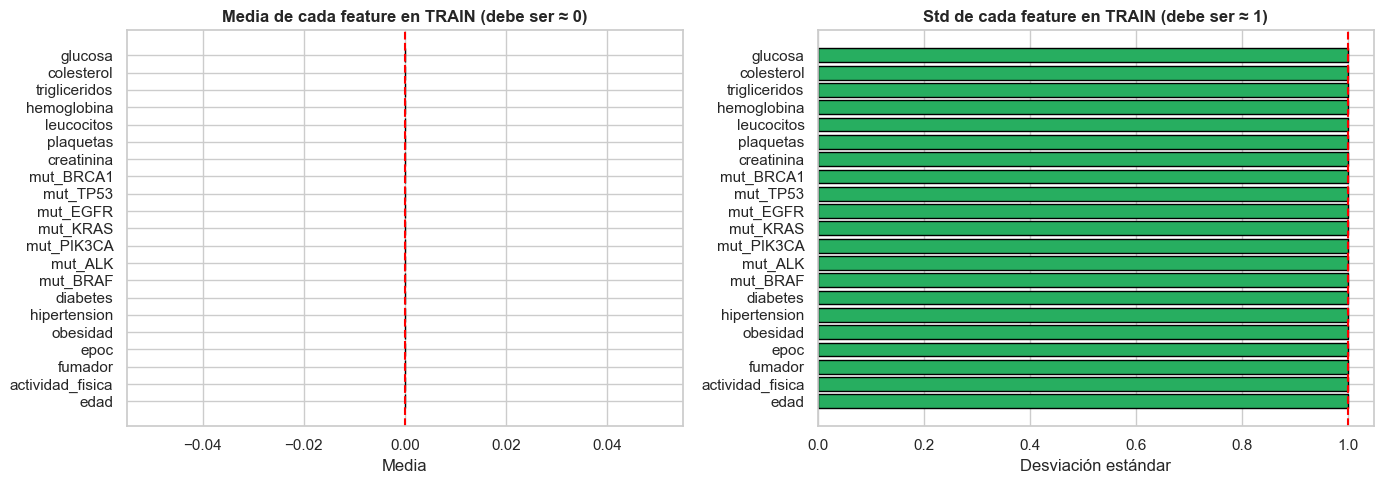

In [3]:
# === VALIDACIÓN 2: Las features están escaladas (media~0, std~1 en train) ===
print("=" * 60)
print("  VALIDACIÓN: ESCALADO CON STANDARDSCALER")
print("=" * 60)

X_train_df = pd.DataFrame(data["X_train"], columns=data["feature_names"])
X_val_df   = pd.DataFrame(data["X_val"],   columns=data["feature_names"])
X_test_df  = pd.DataFrame(data["X_test"],  columns=data["feature_names"])

# Estadísticos por split
stats_train = X_train_df.describe().T[["mean", "std"]].round(4)
stats_train.columns = ["mean_train", "std_train"]
stats_val   = X_val_df.describe().T[["mean", "std"]].round(4)
stats_val.columns   = ["mean_val", "std_val"]
stats_test  = X_test_df.describe().T[["mean", "std"]].round(4)
stats_test.columns  = ["mean_test", "std_test"]

stats = pd.concat([stats_train, stats_val, stats_test], axis=1)
display(stats)

print("\nLectura esperada:")
print("  - mean_train  ≈ 0.0    (StandardScaler ajustado con train)")
print("  - std_train   ≈ 1.0    (idem)")
print("  - mean_val/test pueden desviarse ligeramente de 0 (es lo correcto:")
print("    si fueran exactamente 0, habría data leakage del scaler).")

# Visualización: comparativa de medias y std en train
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(stats.index, stats["mean_train"], color="#3498db", edgecolor="black")
axes[0].axvline(x=0, color="red", linestyle="--", linewidth=1.5)
axes[0].set_title("Media de cada feature en TRAIN (debe ser ≈ 0)", fontweight="bold")
axes[0].set_xlabel("Media")
axes[0].invert_yaxis()

axes[1].barh(stats.index, stats["std_train"], color="#27ae60", edgecolor="black")
axes[1].axvline(x=1, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Std de cada feature en TRAIN (debe ser ≈ 1)", fontweight="bold")
axes[1].set_xlabel("Desviación estándar")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "10_escalado_validacion.png", dpi=120, bbox_inches="tight")
plt.show()

## Validación 3: Class weights y desbalance

  VALIDACIÓN: CLASS WEIGHTS BALANCEADOS

  En train:
    No cáncer (0): 24,214  (80.71%)  → peso: 0.6195
    Cáncer    (1):  5,786  (19.29%)  → peso: 2.5925

  Ratio peso_pos / peso_neg = 4.18
  Ratio desbalance n_neg/n_pos = 4.18

  Como esperamos, el ratio de pesos es la INVERSA del desbalance:
  la clase minoritaria recibe un peso mayor para que los modelos
  presten más atención a sus errores durante el entrenamiento.


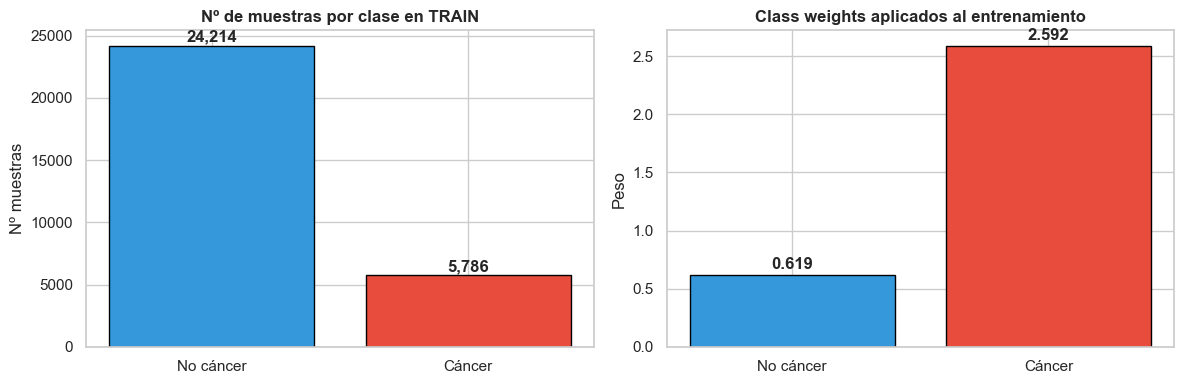

In [4]:
# === VALIDACIÓN 3: Class weights ===
print("=" * 60)
print("  VALIDACIÓN: CLASS WEIGHTS BALANCEADOS")
print("=" * 60)

cw = data["class_weights"]
n_train = len(data["y_train"])
n_pos = int(data["y_train"].sum())
n_neg = n_train - n_pos

print(f"\n  En train:")
print(f"    No cáncer (0): {n_neg:>6,}  ({n_neg/n_train*100:.2f}%)  → peso: {cw[0]:.4f}")
print(f"    Cáncer    (1): {n_pos:>6,}  ({n_pos/n_train*100:.2f}%)  → peso: {cw[1]:.4f}")
print(f"\n  Ratio peso_pos / peso_neg = {cw[1]/cw[0]:.2f}")
print(f"  Ratio desbalance n_neg/n_pos = {n_neg/n_pos:.2f}")
print(f"\n  Como esperamos, el ratio de pesos es la INVERSA del desbalance:")
print(f"  la clase minoritaria recibe un peso mayor para que los modelos")
print(f"  presten más atención a sus errores durante el entrenamiento.")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución de muestras
axes[0].bar(["No cáncer", "Cáncer"], [n_neg, n_pos],
            color=["#3498db", "#e74c3c"], edgecolor="black")
axes[0].set_title("Nº de muestras por clase en TRAIN", fontweight="bold")
axes[0].set_ylabel("Nº muestras")
for i, v in enumerate([n_neg, n_pos]):
    axes[0].text(i, v + 300, f"{v:,}", ha="center", fontweight="bold")

# Pesos asignados
axes[1].bar(["No cáncer", "Cáncer"], [cw[0], cw[1]],
            color=["#3498db", "#e74c3c"], edgecolor="black")
axes[1].set_title("Class weights aplicados al entrenamiento", fontweight="bold")
axes[1].set_ylabel("Peso")
for i, v in enumerate([cw[0], cw[1]]):
    axes[1].text(i, v + 0.05, f"{v:.3f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "11_class_weights.png", dpi=120, bbox_inches="tight")
plt.show()

## Persistencia y resumen final

In [5]:
# === PERSISTENCIA: guardar todo en disco para las fases 3-7 ===
print("Guardando splits procesados en disco...\n")
save_splits(data)

print("\n" + "=" * 60)
print("  FASE 2 COMPLETADA")
print("=" * 60)
print(f"  ✓ 21 features seleccionadas y validadas")
print(f"  ✓ Split estratificado 60/20/20 con prevalencia 19.29% en cada uno")
print(f"  ✓ StandardScaler ajustado solo con train (sin data leakage)")
print(f"  ✓ Class weights balanceados calculados (0.62 / 2.59)")
print(f"  ✓ Datos persistidos en data/processed/ y models/scaler.joblib")
print(f"\nListo para Fase 3: entrenamiento de modelos clásicos de ML.")

Guardando splits procesados en disco...

  Splits guardados en: C:\Users\alvar\Desktop\proyecto-cancer-ia\data\processed
  Scaler guardado en:  C:\Users\alvar\Desktop\proyecto-cancer-ia\models\scaler.joblib

  FASE 2 COMPLETADA
  ✓ 21 features seleccionadas y validadas
  ✓ Split estratificado 60/20/20 con prevalencia 19.29% en cada uno
  ✓ StandardScaler ajustado solo con train (sin data leakage)
  ✓ Class weights balanceados calculados (0.62 / 2.59)
  ✓ Datos persistidos en data/processed/ y models/scaler.joblib

Listo para Fase 3: entrenamiento de modelos clásicos de ML.
